In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import zipfile
import requests
import io

url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

response = requests.get(url)

zip_file = zipfile.ZipFile(io.BytesIO(response.content))
zip_file.extractall("/content")

print("Dataset downloaded and extracted successfully!")

Dataset downloaded and extracted successfully!


In [4]:
# Load ratings and movies files

ratings = pd.read_csv("/content/ml-latest-small/ratings.csv")
movies = pd.read_csv("/content/ml-latest-small/movies.csv")

print("Ratings Dataset:")
display(ratings.head())

print("\nMovies Dataset:")
display(movies.head())

Ratings Dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Movies Dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

print("\nRatings Information:")
ratings.info()

print("\nMovies Information:")
movies.info()

Ratings Shape: (100836, 4)
Movies Shape: (9742, 3)

Ratings Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Movies Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [6]:
print("Missing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in movies:")
print(movies.isnull().sum())

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64


In [7]:
# Merge both datasets using movieId

movie_data = pd.merge(ratings, movies, on="movieId")

print("Merged Dataset:")
display(movie_data.head())

Merged Dataset:


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [8]:
# Create a matrix where:
# rows = users
# columns = movies
# values = ratings

user_movie_matrix = movie_data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

print("User-Movie Matrix Shape:", user_movie_matrix.shape)

display(user_movie_matrix.head())

User-Movie Matrix Shape: (610, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
movie_name = "Toy Story (1995)"

print("Selected Movie:", movie_name)

Selected Movie: Toy Story (1995)


In [10]:
# Get ratings of the selected movie
movie_ratings = user_movie_matrix[movie_name]

# Calculate correlation with all other movies
similar_movies = user_movie_matrix.corrwith(movie_ratings)

# Convert result into DataFrame
similar_movies = pd.DataFrame(
    similar_movies,
    columns=["Correlation"]
)

# Remove movies with no correlation value
similar_movies.dropna(inplace=True)

# Sort by correlation
similar_movies = similar_movies.sort_values(
    "Correlation",
    ascending=False
)

print("Most Similar Movies:")
display(similar_movies.head(11))

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Most Similar Movies:


,Correlation
title,
"Wolfman, The (2010)",1.0
"Big Tease, The (1999)",1.0
Persuasion (2007),1.0
"Perfect Candidate, A (1996)",1.0
Project X (1987),1.0
When in Rome (2010),1.0
Wheels on Meals (Kuai can che) (1984),1.0
Dirty Grandpa (2016),1.0
Escaflowne: The Movie (Escaflowne) (2000),1.0


In [11]:
# Count number of ratings for each movie
movie_rating_counts = movie_data.groupby("title")["rating"].count()

# Add rating count
similar_movies["Rating Count"] = similar_movies.index.map(
    movie_rating_counts
)

# Only consider movies with at least 50 ratings
recommendations = similar_movies[
    similar_movies["Rating Count"] >= 50
]

print("Recommended Movies:")
display(recommendations.head(10))

Recommended Movies:


,Correlation,Rating Count
title,,
Toy Story (1995),1.000000,215
Toy Story 2 (1999),0.699211,97
Arachnophobia (1990),0.652424,53
"Incredibles, The (2004)",0.643301,125
Finding Nemo (2003),0.618701,141
Aladdin (1992),0.611892,183
Erin Brockovich (2000),0.598016,70
Wallace & Gromit: The Wrong Trousers (1993),0.589625,56
Blazing Saddles (1974),0.585892,62


In [12]:
def recommend_movies(movie_name, number_of_recommendations=10):
    """
    Recommend movies similar to the selected movie
    using collaborative filtering.
    """

    if movie_name not in user_movie_matrix.columns:
        print("Movie not found in dataset.")
        return

    # Get ratings for selected movie
    movie_ratings = user_movie_matrix[movie_name]

    # Calculate correlation
    correlations = user_movie_matrix.corrwith(movie_ratings)

    # Create DataFrame
    recommendations = pd.DataFrame(
        correlations,
        columns=["Correlation"]
    )

    recommendations.dropna(inplace=True)

    # Count ratings
    recommendations["Rating Count"] = recommendations.index.map(
        movie_rating_counts
    )

    # Remove selected movie
    recommendations = recommendations[
        recommendations.index != movie_name
    ]

    # Require minimum number of ratings
    recommendations = recommendations[
        recommendations["Rating Count"] >= 50
    ]

    # Sort by similarity
    recommendations = recommendations.sort_values(
        "Correlation",
        ascending=False
    )

    return recommendations.head(number_of_recommendations)

In [13]:
recommendations = recommend_movies(
    "Toy Story (1995)",
    10
)

print("Movies Recommended for: Toy Story (1995)")
display(recommendations)

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Movies Recommended for: Toy Story (1995)


,Correlation,Rating Count
title,,
Toy Story 2 (1999),0.699211,97
Arachnophobia (1990),0.652424,53
"Incredibles, The (2004)",0.643301,125
Finding Nemo (2003),0.618701,141
Aladdin (1992),0.611892,183
Erin Brockovich (2000),0.598016,70
Wallace & Gromit: The Wrong Trousers (1993),0.589625,56
Blazing Saddles (1974),0.585892,62
"Wolf of Wall Street, The (2013)",0.578479,54


In [20]:
movie_name = "Matrix, The (1999)"

recommendations = recommend_movies(
    movie_name,
    10
)

print("Movies Recommended for:", movie_name)
display(recommendations)

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Movies Recommended for: Matrix, The (1999)


,Correlation,Rating Count
title,,
Tommy Boy (1995),0.674887,50
Slumdog Millionaire (2008),0.613839,71
Kung Fu Panda (2008),0.612549,54
Interstellar (2014),0.599040,73
Legends of the Fall (1994),0.567155,68
"Dark Knight Rises, The (2012)",0.557125,76
Die Hard (1988),0.544466,145
"Grand Budapest Hotel, The (2014)",0.543633,52
"Matrix Reloaded, The (2003)",0.522551,96


In [16]:
# Get top 10 recommendations safely
if recommendations is not None:
    top_recommendations = recommendations.head(10)

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_recommendations.index[::-1],
        top_recommendations["Correlation"][::-1]
    )

    plt.xlabel("Similarity Score")
    plt.ylabel("Movie")
    plt.title("Top Movie Recommendations")

    plt.tight_layout()
    plt.show()
else:
    print("No recommendations available to plot. Please check if the movie was found in the dataset.")

No recommendations available to plot. Please check if the movie was found in the dataset.


In [18]:
if recommendations is not None:
    recommended_titles = recommendations.index.tolist()

    recommended_movies = movies[
        movies["title"].isin(recommended_titles)
    ]

    print("Recommended Movies with Genres:")
    display(recommended_movies)
else:
    print("No recommendations found, so genres cannot be displayed.")

No recommendations found, so genres cannot be displayed.


In [19]:
# Search for the correct title spelling of 'Matrix' in the dataset
matrix_search = movies[movies['title'].str.contains('Matrix', case=False, na=False)]
display(matrix_search)

,movieId,title,genres
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
4351,6365,"Matrix Reloaded, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX
4639,6934,"Matrix Revolutions, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX
5669,27660,"Animatrix, The (2003)",Action|Animation|Drama|Sci-Fi


In [25]:
movie_name = input("Enter a movie title: ")

recommendations = recommend_movies(movie_name, 10)

if recommendations is not None and not recommendations.empty:
    print("\nRecommended Movies for:", movie_name)
    display(recommendations)
else:
    print("No recommendations found. Please check the movie title.")

Enter a movie title: Inception (2010)


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Recommended Movies for: Inception (2010)


,Correlation,Rating Count
title,,
"Full Monty, The (1997)",0.909324,56
"Crow, The (1994)",0.859338,64
Grumpier Old Men (1995),0.836421,52
Hook (1991),0.817990,53
Desperado (1995),0.807960,66
Interview with the Vampire: The Vampire Chronicles (1994),0.789059,109
Super Size Me (2004),0.779720,50
Maverick (1994),0.773249,74
Leaving Las Vegas (1995),0.753912,76


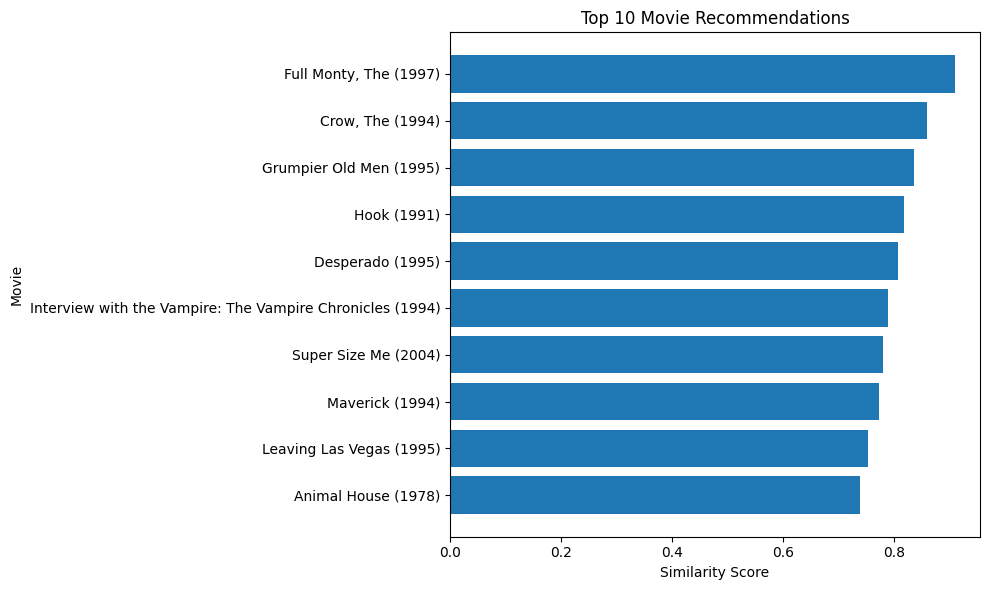

In [26]:
# Get top 10 recommendations
if recommendations is not None and not recommendations.empty:

    top_recommendations = recommendations.head(10)

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_recommendations.index[::-1],
        top_recommendations["Correlation"][::-1]
    )

    plt.xlabel("Similarity Score")
    plt.ylabel("Movie")
    plt.title("Top 10 Movie Recommendations")

    plt.tight_layout()
    plt.show()

else:
    print("No recommendations available to plot.")

In [27]:
movie_name = "Matrix, The (1999)"

recommendations = recommend_movies(movie_name, 10)

print("Movies Recommended for:", movie_name)
display(recommendations)

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Movies Recommended for: Matrix, The (1999)


,Correlation,Rating Count
title,,
Tommy Boy (1995),0.674887,50
Slumdog Millionaire (2008),0.613839,71
Kung Fu Panda (2008),0.612549,54
Interstellar (2014),0.599040,73
Legends of the Fall (1994),0.567155,68
"Dark Knight Rises, The (2012)",0.557125,76
Die Hard (1988),0.544466,145
"Grand Budapest Hotel, The (2014)",0.543633,52
"Matrix Reloaded, The (2003)",0.522551,96
